# 하위 그래프 사용하기 : 기상 전문가와 범용 에이전트

In [ ]:
# 하나의 노드가 '그래프' 일수도 있다.  즉, 그래프 안에 그래프를 사용할수 있다.
# 하위 그래프는 독립적으로도 잘 동작하는 하나의 워크플로로 구성하고,
# 상위 그래프에서 이를 재사용하는 방식이 바람직.

# 모듈화를 잘하면 테스트도 편해지고, 재사용성, 확장성 용이합니다.


![](https://www.dropbox.com/scl/fi/9yr63wtbdbk3j5yzd1zfq/5bc50dab-a02b-453d-8581-f4d25a43ce60.png?rlkey=bls3dvfn620mtemi9d1kotyns&st=u7yozvf3&dl=1)
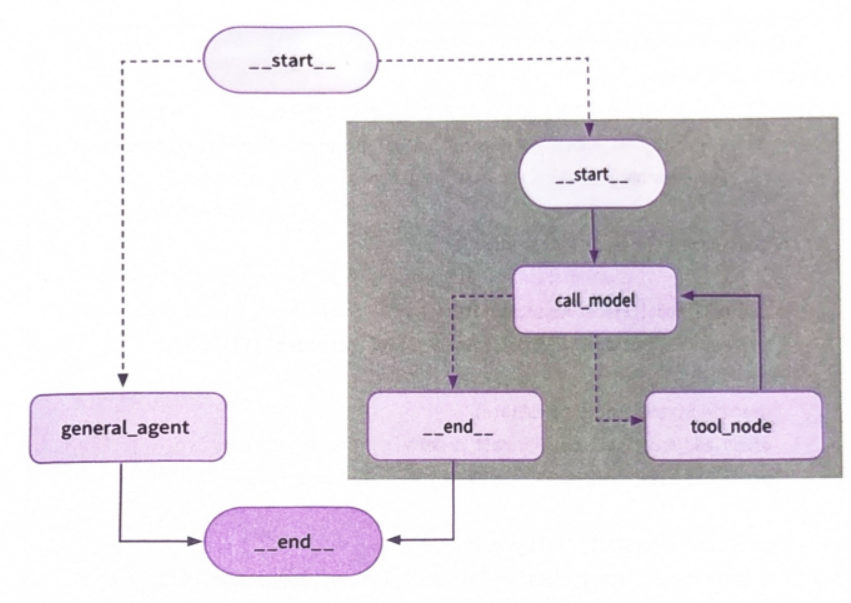

![](https://www.dropbox.com/scl/fi/5y7s92mn1efpl7baeafac/bffe77dd-1ed9-4c67-9061-4c464e260528.png?rlkey=newyrjy9mica9u8xte7ixz0tt&st=1nz4arfw&dl=1)
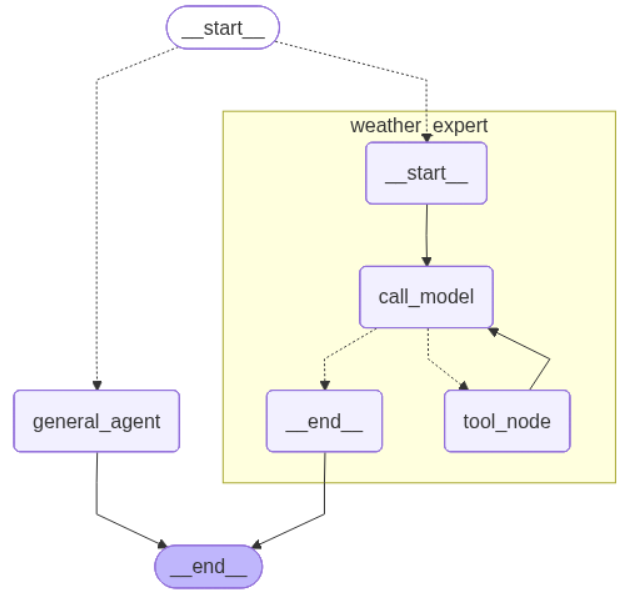

# import

In [1]:
from dotenv import load_dotenv
print(load_dotenv())

import httpx
from geopy.geocoders import Nominatim # pip install geopy
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from langchain.chat_models import init_chat_model
from typing import Literal
import json
from IPython.display import Image, display

True


# 도구

In [2]:
def get_coordinates(city_name: str) -> tuple[float, float]:
    """도시 이름을 받아 위도와 경도를 반환합니다."""
    geolocator = Nominatim(user_agent="weather_app_langgraph")
    location = geolocator.geocode(city_name)
    if location:
        return location.latitude, location.longitude
    raise ValueError(f"좌표를 찾을 수 없습니다: {city_name}")


def get_weather(city_name: str) -> str:
    """도시 이름을 받아 해당 도시의 현재 날씨 정보를 반환합니다."""
    print(f"날씨 조회: {city_name}")
    latitude, longitude = get_coordinates(city_name)
    url = f"https://api.open-meteo.com/v1/forecast?latitude={latitude}&longitude={longitude}&current_weather=true"
    response = httpx.get(url)
    response.raise_for_status()
    return json.dumps(response.json())

# 기상 전문가 서브그래프 생성

In [ ]:
# 기상 전문가 서브그래프 생성: 그동안 보아왔던 코드들과 크게 다른 점은 없습니다. 
# 랭체인의 채팅 모델을 사용하여 모델을 만들고, 툴노드ToolNode를 만들어서 get_weather() 함수를 설정했습니다. 
# 채팅 모델에서 사용자의 메시지를 받고 도구를 호출해야 하면 도구를 사용하는 형태의 그래프를 만들어서 반환합니다.


In [3]:
# ① 기상 전문가 서브그래프 생성
def create_weather_agent():
    """날씨 관련 질문을 처리하는 전문가 서브그래프를 생성합니다."""
    # StateGraph 객체 생성
    graph = StateGraph(MessagesState)

    # tool 바인딩한 ChatModel 생성
    model = init_chat_model('gpt-4o', model_provider='openai').bind_tools([get_weather])

    # Node 생성
    tool_node = ToolNode([get_weather])

    def call_model(state: MessagesState):
        return {"messages": [model.invoke(state['messages'])]}

    # Node 추가
    graph.add_node("call_model", call_model)
    graph.add_node("tool_node", tool_node)

    # Edge 추가
    graph.add_edge(START, 'call_model')
    graph.add_conditional_edges(
        'call_model',
        lambda s: 'tool_node' if s['messages'][-1].tool_calls else END,
        {
            "tool_node": "tool_node",
            END: END,
        }
    )
    graph.add_edge("tool_node", "call_model")

    return graph.compile()

In [4]:
# 테스트: 하위 그래프는 독립적으로도 잘 동작
app = create_weather_agent()

result = app.invoke({"messages": [HumanMessage("부산 날씨 어때?")]})
print(result['messages'][-1].content)


날씨 조회: Busan
부산의 현재 날씨는 다음과 같습니다:

- 기온: 22.9°C
- 풍속: 8.1 km/h
- 풍향: 21°
- 날씨 상태: 맑음 (WMO 코드 1)

지금은 낮입니다.


# 메인 그래프 생성

In [6]:
# router() 함수는 노드를 반환하며 사용자의 메시지를 읽어서 어디에 요청을 보낼지 결정하는 역할을 합니다. 
# 예제 코드에서는 단순하게 메시지에 "날씨" 혹은 "기온"이라는 키워드가 있으면 기상 전문가에게, 
# 아니면 일반 에이전트가 처리하도록 했습니다. 

def router(state: MessagesState) -> Literal["weather_expert", "general_agent"]:
    query = state["messages"][-1].content.lower()
    if "날씨" in query or "기온" in query:
        print("라우팅 결정: 기상 전문가에게 위임")
        return "weather_expert"
        
    print("라우팅 결정: 일반 에이전트가 처리")
    return "general_agent"

# ② 메인 그래프 생성
def create_main_agent(weather_subgraph):  # 매개변수로 서브그래프 받음
    """질문을 라우팅하고 처리하는 메인 에이전트 그래프를 생성합니다."""
    workflow = StateGraph(MessagesState)
    
    main_model = init_chat_model("gpt-4o", model_provider="openai")

    # Node 추가
    workflow.add_node("general_agent", lambda s: {"messages": [main_model.invoke(s['messages'])]})
    
    # 매개변수로 받은 subgraph 를 maingraph 의 노드로 추가!
    workflow.add_node("weather_expert", weather_subgraph)  # ⭐ subgraph 를 node 로 사용 가능!!

    # 조건부 라우팅
    workflow.add_conditional_edges(
        START,
        router,
        {
            "weather_expert": "weather_expert",
            "general_agent": "general_agent",
        },
    )

    # Edge 연결
    workflow.add_edge("general_agent", END)
    workflow.add_edge("weather_expert", END)
    
    return workflow.compile()

# 실행

In [7]:
def main():
    print("=== LangGraph 서브그래프 예제 (기상 전문가) ===\n")

    # Agent(그래프) 생성
    weather_agent = create_weather_agent()
    main_agent = create_main_agent(weather_agent)
    
    queries = ["성남 날씨 어때?", "잠은 몇시간 자는게 좋을까?"]
    
    for query in queries:
        print(f"\n--- 질문: {query} ---")
        result = main_agent.invoke({"messages": [HumanMessage(content=query)]})
        print(f"최종 답변: {result["messages"][-1].content}")
        print("-" * 20)

    # 그래프 시각화
    # xray=True는 그래프 시각화 시 서브그래프(subgraph)의 내부 구조까지 펼쳐서 보여주는 옵션
    return main_agent
    

if __name__ == "__main__":
    main_agent = main()


=== LangGraph 서브그래프 예제 (기상 전문가) ===


--- 질문: 성남 날씨 어때? ---
라우팅 결정: 기상 전문가에게 위임
날씨 조회: Seongnam
최종 답변: 성남의 현재 날씨는 맑으며, 온도는 20.2°C입니다. 바람은 북쪽에서 불며 풍속은 시속 5.1km입니다.
--------------------

--- 질문: 잠은 몇시간 자는게 좋을까? ---
라우팅 결정: 일반 에이전트가 처리
최종 답변: 잠의 적정 시간은 개인마다 다를 수 있지만, 일반적으로 성인은 하루에 7-9시간 정도의 수면을 권장합니다. 이 시간 동안 충분한 깊은 잠과 렘수면을 경험하는 것이 중요합니다. 청소년은 약 8-10시간, 어린이는 9-12시간 정도의 수면이 필요합니다. 자신의 몸 상태와 생활 패턴에 맞는 수면 시간을 찾아 규칙적으로 유지하는 것이 좋습니다.
--------------------


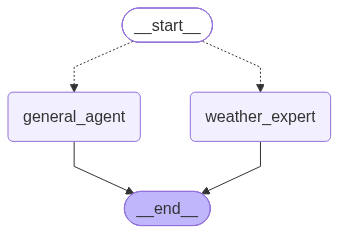

In [8]:
# 시각화
display(Image(main_agent.get_graph().draw_mermaid_png()))

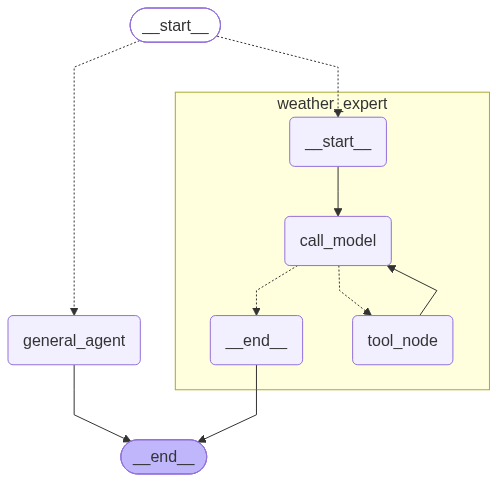

In [9]:
display(Image(main_agent.get_graph(xray=True).draw_mermaid_png()))